Lab 1: Document Processing with OCR

In this lesson, you will build an agent for document processing with optical character recognition (OCR).

Learning Objectives:

    Parsing and extracting information from documents
    Building an agent equipped with an OCR tool
    Identifying failure modes of OCR

Background

Document processing converts unstructured documents meant for humans into structured data meant for machines. When documents are scanned images, OCR converts pixels to text. However, OCR alone produces raw text. Using LLMs, we can make sense of it. 

### 1- Make imports

In [2]:
from PIL import Image

import pytesseract

from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor

from langchain_openai import ChatOpenAI

### 2- Create OCR tool

In [3]:
from langchain.tools import tool

@tool
def ocr_read_doc(image_path: str) -> str:
    """Reads text from an image document using OCR."""
    try:
        text = pytesseract.image_to_string(Image.open(image_path))
        return text
    except Exception as e:
        return f"Error reading document: {e}"

#### 2.1- Use OCR to parse a sample document

In [ ]:
doc_path = 'files/TD_CASH_BACK_VISA_INFINITE__CARD_3226_Feb_06-2026.pdf'

In [ ]:
# turn PDF pages into images
import fitz
from PIL import Image

doc = fitz.open(doc_path)
for i, page in enumerate(doc):
    pix = page.get_pixmap()
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    img.save(f"files/page_{i}.png")

In [ ]:
from IPython.display import display

image_path = 'files/page_0.png'
img = Image.open(image_path)
display(img)

In [4]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

In [5]:
ocr_text = ocr_read_doc.run("files/invoice_sample.png")

print("raw OCR output:\n ---------------------\n", ocr_text)


raw OCR output:
 ---------------------
 Your Company Inc.

1234 Company St,
Company Town, ST 12345

Bill To
Customer Name

1234 Customer St,
Customer Town, ST 12345

@& Upload Logo

INVOICE

Invoice # 0000007
Invoice date 10-02-2023
Due date 10-16-2023

Amount

1.00 Replacement of spark plugs 40.00 $40.00
2.00 Brake pad replacement (front) 40.00 $80.00
4.00 Wheel alignment 17.50 $70.00
2.00 Mechanic's rate per hour 30.00 $60.00
Subtotal $250.00

Sales Tax (5%) $12.50

Total (USD) $262.50

Terms and Conditions
Payment is due in 14 days

Please make checks payable to: Your Company Inc.




#### 2.2. Use Regex to Extract Information

In [10]:
import re
tax_match = re.search(r'Sales Tax\s*\$?([0-9.,]+)', ocr_text)
total_match = re.search(r'Total\s*\$?([0-9.,]+)', ocr_text)

if tax_match:
    print("tax: ", tax_match.group(1))
else:
    print("no match was found")

if total_match:
    print("total: ", total_match.group(1))
else:
    print("no match was found")

no match was found
no match was found


In [11]:
import re

pattern = re.compile(
    r"(?i)\bSales\s*Tax\b\s*[:\-]?\s*([$€]?\s*\d+[.,]\d{2})"
)

match = pattern.search(ocr_text)
tax_value = match.group(1) if match else None
tax_value

In [ ]:
ocr_text

### 3- Create the agent

In [6]:
import os
from dotenv import load_dotenv

_ = load_dotenv(override=True)

In [19]:
# define the tools

tools = [ocr_read_doc]

import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# Define the base URL for the LM Studio server and a placeholder API key
# LM Studio uses an OpenAI-compatible API, so we use ChatOpenAI.
LMSTUDIO_BASE_URL = os.getenv("LMSTUDIO_BASE_URL")
# Use "lm-studio" as the placeholder API key as suggested by LM Studio docs/examples
# If you generated a specific key, replace "lm-studio" with that key.
LMSTUDIO_API_KEY = os.getenv("LMSTUDIO_API_KEY")

# set up the OpenAI model
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(api_key=LMSTUDIO_API_KEY, base_url=LMSTUDIO_BASE_URL, model="google/gemma-3-27b", temperature=1)

In [20]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import create_tool_calling_agent
from langchain_classic.agents import AgentExecutor

prompt = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are a helpful assistant for extracting information from documents."
        "You have access to the following tool for reading documents: ocr_read_doc(image_path: str) -> str. "
    ),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),

])

agent = create_tool_calling_agent(llm, tools, prompt)

agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:


# # Initialize the ChatOpenAI model
# # The model name is a placeholder and doesn't affect the local model loaded in LM Studio
# llm = ChatOpenAI(
#     api_key=LMSTUDIO_API_KEY,
#     base_url=LMSTUDIO_BASE_URL,
#     model_name="gemma-3-4b-it", # Name can be arbitrary but good practice to match the model
#     temperature=0.7 # Adjust temperature as needed
# )

# # Create the prompt messages
# messages = [
#     SystemMessage(content="You are a helpful assistant who provides concise answers."),
#     HumanMessage(content="Explain the role of mitochondria in cell biology.")
# ]

# # Invoke the model to get a response
# response = llm.invoke(messages)

# # Print the response
# print(response.content)

### 4. Run Agent and Extract Info

In [9]:
task = """
Please process the document at 'files/invoice_sample.png' using the OCR tool 
and extract the following information in JSON format:
- tax
- total
"""

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...

Invoking: `ocr_read_doc` with `{'image_path': 'files/invoice_sample.png'}`


Your Company Inc.

1234 Company St,
Company Town, ST 12345

Bill To
Customer Name

1234 Customer St,
Customer Town, ST 12345

@& Upload Logo

INVOICE

Invoice # 0000007
Invoice date 10-02-2023
Due date 10-16-2023

Amount

1.00 Replacement of spark plugs 40.00 $40.00
2.00 Brake pad replacement (front) 40.00 $80.00
4.00 Wheel alignment 17.50 $70.00
2.00 Mechanic's rate per hour 30.00 $60.00
Subtotal $250.00

Sales Tax (5%) $12.50

Total (USD) $262.50

Terms and Conditions
Payment is due in 14 days

Please make checks payable to: Your Company Inc.

```json
{
  "tax": "12.50",
  "total": "262.50"
}
```

> Finished chain.


### 5. OCR Limitations

#### 5.1 Tables

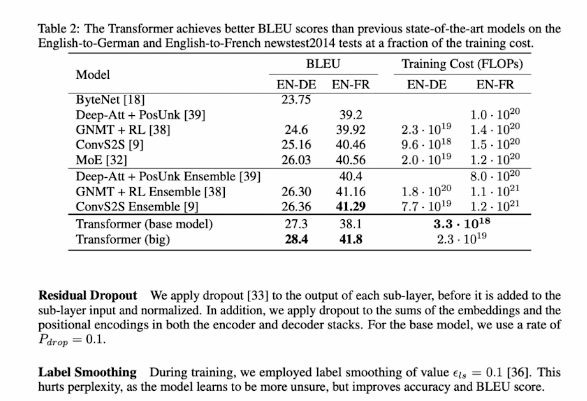

In [13]:
image_path = 'files/table_sample2.png'
img = Image.open(image_path)
display(img)

In [ ]:
# trying gemma-3-4b-it
task = """
Extract the Training Cost (FLOPs) for EN-DE for ALL methods from the image at 'files/table_sample2.png' 
using the OCR tool. only look at the column of TRAINING COST (FLOPs) for EN-DE, not the column BLEU.
Return as a list with model name and its training cost.
"""

# First, get the raw OCR output
ocr_output = ocr_read_doc.run(image_path)

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})

# Display results side by side
print("="*80)
print(" " * 22 + "OCR TABLE RESULTS")
print("="*80)
print("\n" + "─"*35 + " OCR OUTPUT " + "─"*33)
print(ocr_output[:600] + "..." if len(ocr_output) > 600 else ocr_output)
print("\n" + "─"*35 + " LLM RESULT " + "─"*33)
print(response["output"])
print("="*80)



> Entering new AgentExecutor chain...

Invoking: `ocr_read_doc` with `{'image_path': 'files/table_sample2.png'}`


Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the
English-to-German and English-to-French newstest2014 tests at a fraction of the training cost.

Model BLEU ‘Training Cost (FLOPS)
. EN-DE _EN-FR EN-DE ENR
ByteNet [18] B75
Deep-Att + PosUnk [39] 392 1.0- 10
GNMT + RL [38] 246 39.92 -2.3-10! 14-10
ConvS2s [9] 25.16 40.46 —-9.6-10!8 1.5- 10%
MoE [32] 26.03 40.56 __2.0- 10! _1.2- 10
Deep-Att + PosUnk Ensemble [39] 404 8.0- 10
GNMT + RL Ensemble [38] 2630 41.16 18-10% 11-10
ConvS2S Ensemble [9] 2636 41.29 7.7109 _1.2- 10
‘Transformer (base model) 273 381 33-10!
‘Transformer (big) 24 418 23-10"

Residual Dropout We apply dropout [33] to the output of each sub-layer, before it is added to the
sub-layer input and normalized. In addition, we apply dropout to the sums of the embeddings and the
positional encodings in both the encoder

In [ ]:
# trying google/gemma-3-27b
task = """
Extract the Training Cost (FLOPs) for EN-DE for ALL methods from the image at 'files/table_sample2.png' 
using the OCR tool. only look at the column of TRAINING COST (FLOPs) for EN-DE, not the column BLEU.
Return as a list with model name and its training cost.
"""

# First, get the raw OCR output
ocr_output = ocr_read_doc.run(image_path)

# Use .invoke() with a dictionary input for the agent_executor
# response = agent_executor.invoke({"input": task})

# Display results side by side
print("="*80)
print(" " * 22 + "OCR TABLE RESULTS")
print("="*80)
print("\n" + "─"*35 + " OCR OUTPUT " + "─"*33)
print(ocr_output[:600] + "..." if len(ocr_output) > 600 else ocr_output)
print("\n" + "─"*35 + " LLM RESULT " + "─"*33)
print(response["output"])
print("="*80)



> Entering new AgentExecutor chain...

Invoking: `ocr_read_doc` with `{'image_path': 'files/table_sample2.png'}`


Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the
English-to-German and English-to-French newstest2014 tests at a fraction of the training cost.

Model BLEU ‘Training Cost (FLOPS)
. EN-DE _EN-FR EN-DE ENR
ByteNet [18] B75
Deep-Att + PosUnk [39] 392 1.0- 10
GNMT + RL [38] 246 39.92 -2.3-10! 14-10
ConvS2s [9] 25.16 40.46 —-9.6-10!8 1.5- 10%
MoE [32] 26.03 40.56 __2.0- 10! _1.2- 10
Deep-Att + PosUnk Ensemble [39] 404 8.0- 10
GNMT + RL Ensemble [38] 2630 41.16 18-10% 11-10
ConvS2S Ensemble [9] 2636 41.29 7.7109 _1.2- 10
‘Transformer (base model) 273 381 33-10!
‘Transformer (big) 24 418 23-10"

Residual Dropout We apply dropout [33] to the output of each sub-layer, before it is added to the
sub-layer input and normalized. In addition, we apply dropout to the sums of the embeddings and the
positional encodings in both the encoder